In [1]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 94.0 MB/s eta 0:00:00:00:0100:01


In [2]:
# Dữ liệu 
import pandas as pd
import numpy as np

# Ảnh & PyTorch 
import torch
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Tìm kiếm tương đồng
import faiss
from sklearn.metrics.pairwise import cosine_similarity

# Vẽ biểu đồ 
import matplotlib.pyplot as plt
import seaborn as sns

# Tiện ích
import os
from tqdm import tqdm

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 20)      
plt.rcParams['figure.figsize'] = (10, 5)    
sns.set_style('whitegrid')                  


print('Import thư viện thành công!')
print(f'PyTorch version : {torch.__version__}')
# Kiểm tra máy có GPU không. GPU giúp chạy nhanh hơn CPU rất nhiều.
# Laptop bình thường thường sẽ hiện 'cpu' – không sao, vẫn chạy được.
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

Import thư viện thành công!
PyTorch version : 2.11.0+cu128
Device: cuda


DÙNG GG COLAB MƯỢN GPU T4

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

# ĐƯỜNG DẪN ĐÚNG DỰA TRÊN ẢNH GOOGLE DRIVE CỦA BẠN:
DATA_DIR = '/content/drive/MyDrive/DoAnPython/DuLieuPython'

CSV_PATH = os.path.join(DATA_DIR, 'train.csv')
# Vì 'train_images.zip' đang là file nén, bạn cứ khai báo đường dẫn tệp trước:
IMAGE_ZIP_PATH = os.path.join(DATA_DIR, 'train_images.zip') 

PROCESSED = '../data/processed/'
RESULTS = '../results/'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

# Kiểm tra lại đường dẫn
for p in [CSV_PATH, IMAGE_ZIP_PATH]:
    status = 'Đã tìm thấy tệp/thư mục' if os.path.exists(p) else 'Không tìm thấy – kiểm tra lại đường dẫn!'
    print(f'{status}  {p}')

Đã tìm thấy tệp/thư mục  /content/drive/MyDrive/DoAnPython/DuLieuPython/train.csv
Đã tìm thấy tệp/thư mục  /content/drive/MyDrive/DoAnPython/DuLieuPython/train_images.zip


TIỀN XỬ LÝ DỮ LIỆU

In [5]:
class ShopeeDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            img_name = self.df.iloc[idx]['image']
            img_path = os.path.join(self.img_dir, img_name)
            image = self.transform(Image.open(img_path).convert("RGB"))
        except Exception:
            image = torch.zeros(3, 224, 224)
            
        text = str(self.df.iloc[idx]['title'])
        text_token = clip.tokenize([text], truncate=True).squeeze(0)
        return image, text_token

In [6]:
df = pd.read_csv(CSV_PATH)

print(f'Train: {df.shape[0]:,} dòng x {df.shape[1]:,} cột')

df.head()

Train: 34,250 dòng x 5 cột


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   posting_id   34250 non-null  object
 1   image        34250 non-null  object
 2   image_phash  34250 non-null  object
 3   title        34250 non-null  object
 4   label_group  34250 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.3+ MB


In [8]:
candidate_df = pd.read_csv(CSV_PATH)

TẢI MÔ HÌNH CLIP

In [9]:
!pip install sentence-transformers timm
import torch
from sentence_transformers import SentenceTransformer
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"
# Sửa đổi chuỗi tên định danh DINOv3 chuẩn xác trong thư viện timm
dinov3_model = timm.create_model("vit_base_patch16_dinov3.lvd1689m", pretrained=True, num_classes=0).to(device)
dinov3_model.eval()
minilm_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

TRÍCH XUẤT VECTO

In [10]:
!unzip -q /content/drive/MyDrive/DoAnPython/DuLieuPython/train_images.zip -d /content/train_images_extracted

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
import timm

csv_path = "/content/drive/MyDrive/DoAnPython/DuLieuPython/train.csv"
image_folder = "/content/train_images_extracted/train_images"
candidate_df = pd.read_csv(csv_path)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tải mô hình với tên chuẩn hóa
dinov3_model = timm.create_model("vit_base_patch16_dinov3.lvd1689m", pretrained=True, num_classes=0).to(device)
dinov3_model.eval()
minilm_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# Tự động lấy cấu hình tiền xử lý ảnh chuẩn (kích thước, mean, std) từ chính mô hình DINOv3
data_config = timm.data.resolve_model_data_config(dinov3_model)
dinov3_transform = timm.data.create_transform(**data_config, is_training=False)

class ShopeeDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["image"]
        img_path = os.path.join(self.img_dir, img_name)
        try:
            image = self.transform(Image.open(img_path).convert("RGB"))
        except Exception:
            # Fallback tạo tensor trống khớp chính xác kích thước yêu cầu của mô hình
            image = torch.zeros(3, data_config['input_size'][1], data_config['input_size'][2])
        text = str(self.df.iloc[idx]["title"])
        return image, text

dataset = ShopeeDataset(candidate_df, image_folder, dinov3_transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=2)

image_features_list = []
titles_list = []

for images, texts in tqdm(dataloader):
    images = images.to(device)
    with torch.no_grad():
        img_features = dinov3_model(images)
    img_features /= img_features.norm(dim=-1, keepdim=True)
    image_features_list.append(img_features.cpu())
    titles_list.extend(texts)

image_features = torch.cat(image_features_list, dim=0).numpy()
text_features = minilm_model.encode(titles_list, batch_size=128, show_progress_bar=True, convert_to_numpy=True)

output_dir = "/content/drive/MyDrive/DoAnPython/DuLieuPython"
np.save(os.path.join(output_dir, "dinov3_image_features.npy"), image_features)
np.save(os.path.join(output_dir, "minilm_text_features.npy"), text_features)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 268/268 [08:50<00:00,  1.98s/it]


Batches:   0%|          | 0/268 [00:00<?, ?it/s]

: 

TÍNH TOÁN MA TRẬN TƯƠNG ĐỒNG

In [1]:
import os
import gc  # Thêm thư viện giải phóng rác tự động
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

csv_path = "/content/drive/MyDrive/DoAnPython/DuLieuPython/train.csv"
output_dir = "/content/drive/MyDrive/DoAnPython/DuLieuPython"

candidate_df = pd.read_csv(csv_path)
dinov3_image_features = np.load(os.path.join(output_dir, "dinov3_image_features.npy")).astype('float32')
minilm_text_features = np.load(os.path.join(output_dir, "minilm_text_features.npy")).astype('float32')

device = "cuda" if torch.cuda.is_available() else "cpu"

image_tensor = torch.tensor(dinov3_image_features).to(device)
text_tensor = torch.tensor(minilm_text_features).to(device)

# Chuẩn hóa L2
image_norm = image_tensor / image_tensor.norm(dim=-1, keepdim=True)
text_norm = text_tensor / text_tensor.norm(dim=-1, keepdim=True)

phash_strings = candidate_df["image_phash"].values
phash_ints = np.array([int(h, 16) for h in phash_strings], dtype=np.uint64)

num_samples = len(candidate_df)
BATCH_SIZE = 1024
all_sorted_indices = []

# ==================== CẤU HÌNH QUAN TRỌNG ====================
# Thay vì lưu toàn bộ N x N thứ tự (gây tràn RAM), chỉ lấy Top K kết quả cao nhất.
# Nếu bắt buộc phải lưu toàn bộ ma trận (không khuyến khích), hãy đặt TOP_K = None
TOP_K = 50 
# =============================================================

torch.cuda.empty_cache()
gc.collect()

for start_idx in tqdm(range(0, num_samples, BATCH_SIZE)):
    end_idx = min(start_idx + BATCH_SIZE, num_samples)
    
    # 1. Tính toán tương đồng trên GPU
    img_sim_batch = torch.matmul(image_norm[start_idx:end_idx], image_norm.T)
    txt_sim_batch = torch.matmul(text_norm[start_idx:end_idx], text_norm.T)
    
    # Kết hợp trọng số và đẩy NGAY về CPU dạng float32 để giải phóng GPU
    sim_batch = (0.7 * img_sim_batch + 0.3 * txt_sim_batch).cpu().numpy().astype(np.float32)
    
    # Giải phóng biến GPU ngay lập tức
    del img_sim_batch, txt_sim_batch
    torch.cuda.empty_cache()
    
    # 2. Tối ưu tính Khoảng cách Hamming (Thuật toán Bit-twiddling song song siêu tốc)
    batch_phash = phash_ints[start_idx:end_idx]
    phash_diff = batch_phash[:, None] ^ phash_ints[None, :]
    
    # Đếm số bit 1 bằng toán tử bitwise thay vì chạy vòng lặp 64 lần
    x = phash_diff
    x = (x & 0x5555555555555555) + ((x >> 1) & 0x5555555555555555)
    x = (x & 0x3333333333333333) + ((x >> 2) & 0x3333333333333333)
    x = (x & 0x0F0F0F0F0F0F0F0F) + ((x >> 4) & 0x0F0F0F0F0F0F0F0F)
    x = (x & 0x00FF00FF00FF00FF) + ((x >> 8) & 0x00FF00FF00FF00FF)
    x = (x & 0x0000FFFF0000FFFF) + ((x >> 16) & 0x0000FFFF0000FFFF)
    hamming_dist = ((x & 0x00000000FFFFFFFF) + (x >> 32)).astype(np.uint8)
    
    del phash_diff, x
    
    # 3. Cộng điểm trực tiếp (In-place) lên ma trận cũ, KHÔNG dùng np.where tạo bản sao mới
    # Nếu khoảng cách <= 2 thì cộng thêm 0.5. Nếu bằng 0 (giống hệt) thì cộng thêm 0.5 nữa (tổng là 1.0)
    sim_batch[hamming_dist <= 2] += 0.5
    sim_batch[hamming_dist == 0] += 0.5
    
    del hamming_dist
    
    # 4. Sắp xếp và trích xuất chỉ mục (Ép kiểu về int32 để giảm 50% dung lượng RAM)
    if TOP_K is not None:
        # Chỉ lấy Top K phần tử lớn nhất, cắt bỏ phần thừa ngay lập tức để tiết kiệm bộ nhớ
        sorted_indices = np.argsort(-sim_batch, axis=-1)[:, :TOP_K].astype(np.int32)
    else:
        sorted_indices = np.argsort(-sim_batch, axis=-1).astype(np.int32)
        
    all_sorted_indices.append(sorted_indices)
    
    del sim_batch
    gc.collect() # Dọn dẹp bộ nhớ đệm CPU sau mỗi Batch

# Gộp toàn bộ kết quả cực kỳ nhẹ nhàng
all_sorted_indices = np.vstack(all_sorted_indices)
np.save(os.path.join(output_dir, "all_sorted_indices.npy"), all_sorted_indices)

print(f"Thành công! Đã xử lý và lưu file. Hình dạng ma trận đầu ra: {all_sorted_indices.shape}")

100%|██████████| 34/34 [01:48<00:00,  3.21s/it]

Thành công! Đã xử lý và lưu file. Hình dạng ma trận đầu ra: (34250, 50)


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/DoAnPython/DuLieuPython"))

['train.csv', 'train_images.zip', 'train_synced.csv', 'data', 'results', 'processed', 'train_images', 'clip_text_features.npy', 'clip_image_features.npy']


TÍNH TOÁN METRIC

In [2]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

csv_path = "/content/drive/MyDrive/DoAnPython/DuLieuPython/train.csv"
output_dir = "/content/drive/MyDrive/DoAnPython/DuLieuPython"

candidate_df = pd.read_csv(csv_path)
all_sorted_indices = np.load(os.path.join(output_dir, "all_sorted_indices.npy"))

labels = candidate_df["label_group"].values
group_to_indices = candidate_df["label_group"].groupby(candidate_df["label_group"]).indices
num_samples = len(labels)

ap5_scores = []
p1, r1 = [], []
p3, r3 = [], []
p5, r5 = [], []
p10, r10 = [], []

for i in tqdm(range(num_samples)):
    retrieved_indices = all_sorted_indices[i]
    query_label = labels[i]
    ground_truth_indices = group_to_indices[query_label]

    retrieved_indices = retrieved_indices[retrieved_indices != i]
    gt_without_self = ground_truth_indices[ground_truth_indices != i]
    gt_len = len(gt_without_self)

    if gt_len > 0:
        is_relevant = np.isin(retrieved_indices, gt_without_self)
        
        h1 = is_relevant[:1].sum()
        p1.append(h1 / 1)
        r1.append(h1 / gt_len)

        h3 = is_relevant[:3].sum()
        p3.append(h3 / 3)
        r3.append(h3 / gt_len)

        h5 = is_relevant[:5].sum()
        p5.append(h5 / 5)
        r5.append(h5 / gt_len)

        h10 = is_relevant[:10].sum()
        p10.append(h10 / 10)
        r10.append(h10 / gt_len)

        is_relevant_5 = is_relevant[:5]
        hit_positions = np.where(is_relevant_5)[0] + 1
        if len(hit_positions) > 0:
            hits_cum = np.arange(1, len(hit_positions) + 1)
            ap_5 = np.sum(hits_cum / hit_positions) / min(5, gt_len)
            ap5_scores.append(ap_5)
        else:
            ap5_scores.append(0.0)
    else:
        p1.append(0.0); r1.append(0.0)
        p3.append(0.0); r3.append(0.0)
        p5.append(0.0); r5.append(0.0)
        p10.append(0.0); r10.append(0.0)
        ap5_scores.append(0.0)

summary_metrics = pd.DataFrame(
    {
        "K": [1, 3, 5, 10],
        "Precision": [np.mean(p1), np.mean(p3), np.mean(p5), np.mean(p10)],
        "Recall": [np.mean(r1), np.mean(r3), np.mean(r5), np.mean(r10)],
    }
)

summary_metrics[["Precision", "Recall"]] = summary_metrics[["Precision", "Recall"]].round(4)
map_at_5 = round(np.mean(ap5_scores), 4)

print(summary_metrics.to_string(index=False))
print(map_at_5)

100%|██████████| 34250/34250 [00:02<00:00, 12856.10it/s]

 K  Precision  Recall
 1     0.7729  0.3987
 3     0.5388  0.6218
 5     0.4244  0.7119
10     0.2851  0.8074
0.7388


Cell 8

--- TOP 5 QUERIES TRẢ VỀ SAI NHIỀU NHẤT VÀ HÌNH ẢNH MINH HỌA ---

Query Index: 34226 | Title: 'ERTOS EYEBAG/ EYE CIRCLE SERUM' | Label: 2011346792 | Sai: 5/5


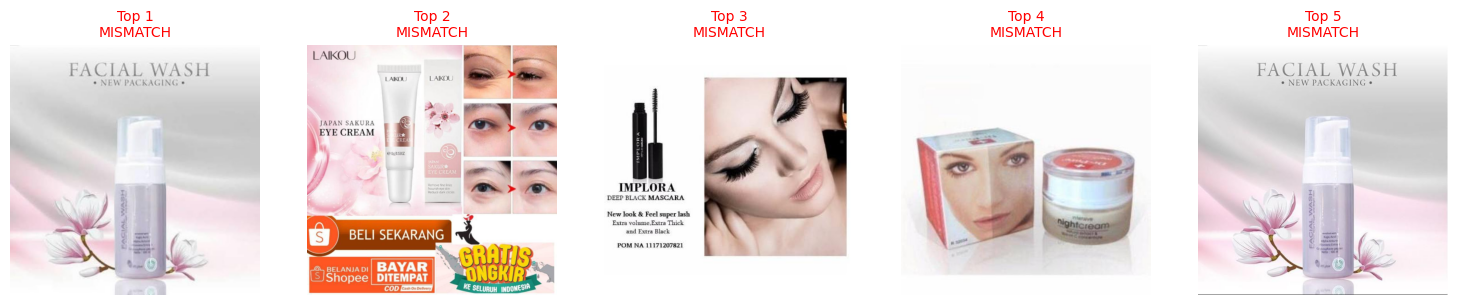


Query Index: 34205 | Title: 'masker anak bahan scuba halus produk import' | Label: 2542343288 | Sai: 5/5


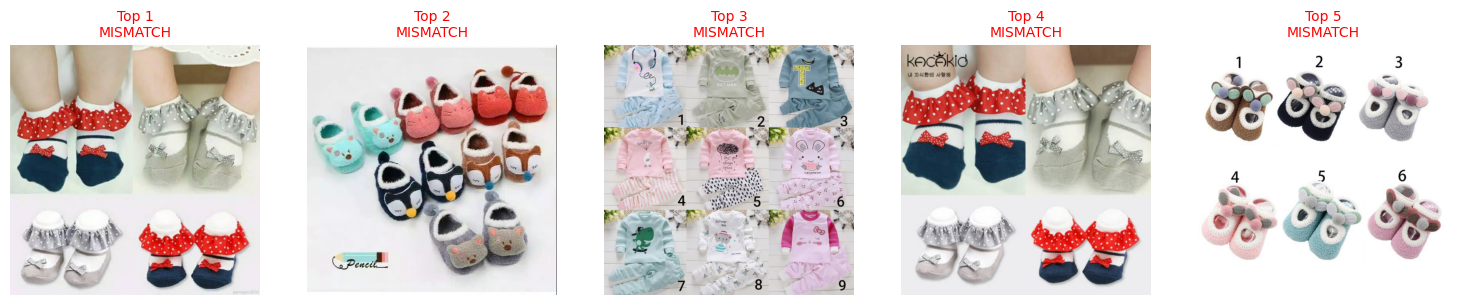


Query Index: 34240 | Title: 'Kepala Sower Mandi Aerator Air Soft Halus Lembut 300 Lubang Low Preasure Premium BN28' | Label: 132875370 | Sai: 5/5


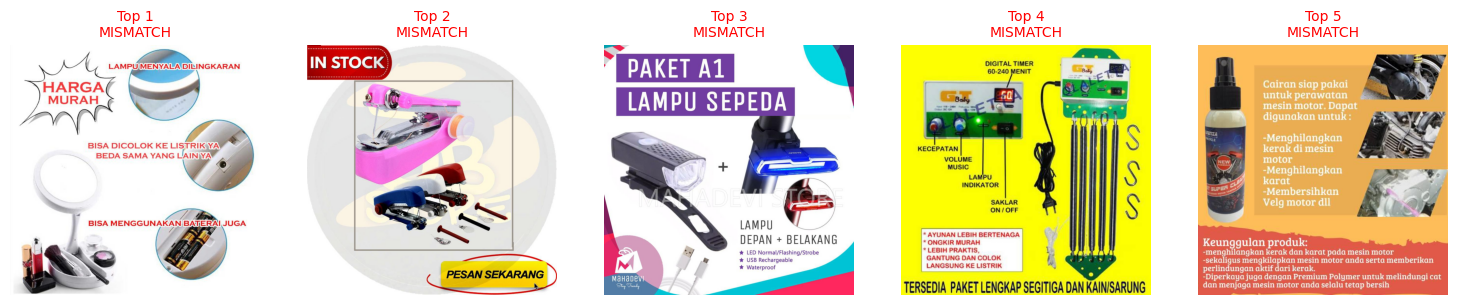


Query Index: 66 | Title: 'Anti Blue Light Film Sony Xperia XZ1 XZ3 XZ/XZ2 Premium XA2 Plus/Ultra Xperia 1 10 Plus Screen Guard' | Label: 1702111919 | Sai: 5/5


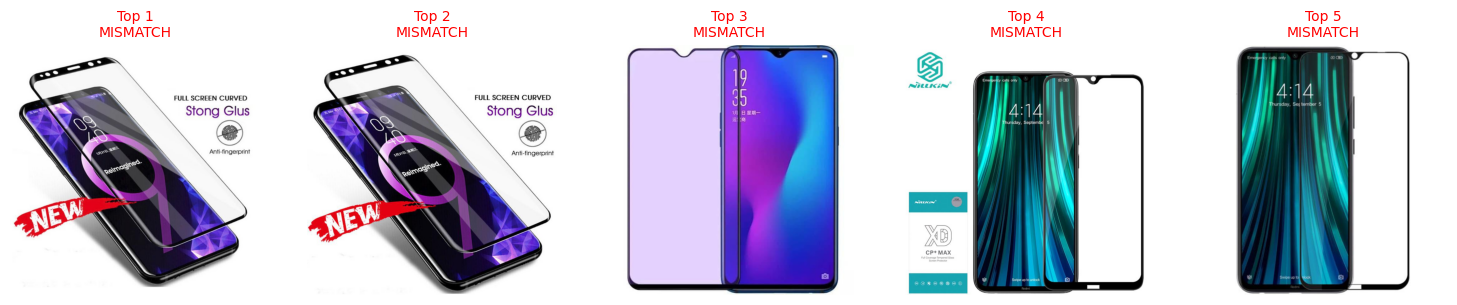


Query Index: 69 | Title: 'CUKA APEL BRAGG [MURNI 100% 60 ML]' | Label: 3798328212 | Sai: 5/5


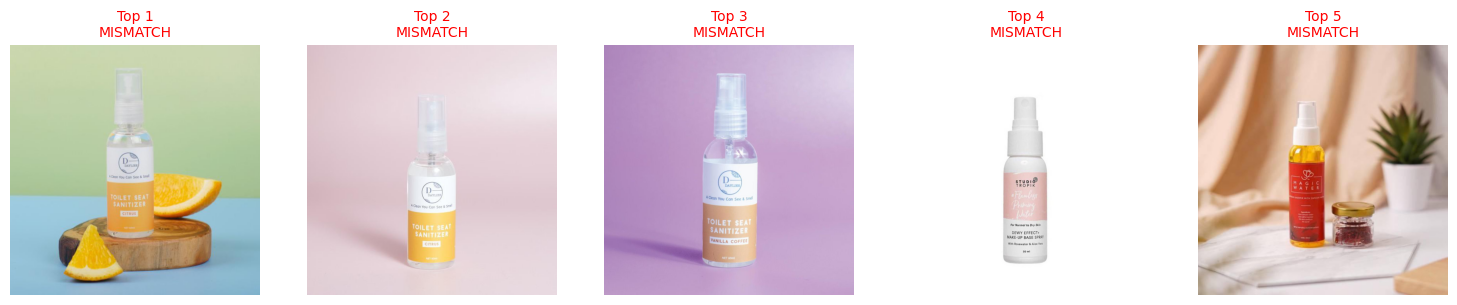


--- TOP 5 BỨC ẢNH GÂY NHIỄU / DỄ BỊ NHẬN NHẦM NHẤT ---
Ảnh Index: 3693 | File: 1c3d02297beb3211c2c122e9a39c42a5.jpg | Bị nhận nhầm: 140 lần
Ảnh Index: 3630 | File: 1bc40def305c8666f419bc5e95a038cd.jpg | Bị nhận nhầm: 66 lần
Ảnh Index: 28324 | File: d3dced074a659b908a5316d8a94201ce.jpg | Bị nhận nhầm: 63 lần
Ảnh Index: 26987 | File: c9e353d0db0d37c485f09973a04cea6e.jpg | Bị nhận nhầm: 57 lần
Ảnh Index: 10548 | File: 4f23dbd23ba800b544a2df6e85a8ed14.jpg | Bị nhận nhầm: 55 lần


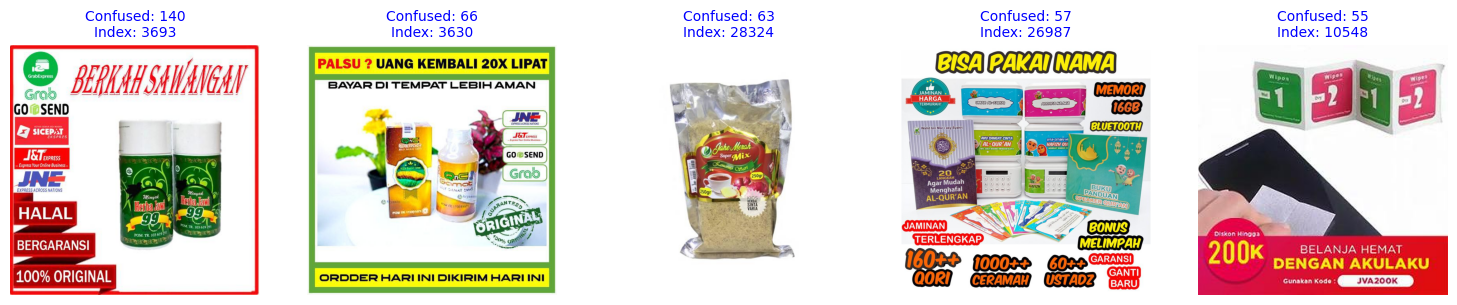

In [ ]:
import torch
import numpy as np
import pandas as pd
from collections import Counter
import os
import matplotlib.pyplot as plt
from PIL import Image

csv_path = "/content/drive/MyDrive/DoAnPython/DuLieuPython/train.csv"
output_dir = "/content/drive/MyDrive/DoAnPython/DuLieuPython"
image_folder = "/content/train_images_extracted/train_images"

candidate_df = pd.read_csv(csv_path)
image_features = np.load(os.path.join(output_dir, "clip_image_features.npy"))

device = "cuda" if torch.cuda.is_available() else "cpu"
image_features_tensor = torch.tensor(image_features).to(device)

cosine_similarity_matrix = torch.matmul(image_features_tensor, image_features_tensor.T)

K = 5
topk_indices_raw = torch.topk(cosine_similarity_matrix, k=K + 1, dim=1)[1].cpu().numpy()

label_groups = candidate_df['label_group'].values
num_samples = len(label_groups)
wrong_counts = []
false_positives = []
topk_indices = []

for i in range(num_samples):
    query_label = label_groups[i]
    retrieved_indices = topk_indices_raw[i]
    retrieved_indices = retrieved_indices[retrieved_indices != i][:K]
    topk_indices.append(retrieved_indices)
    
    retrieved_labels = label_groups[retrieved_indices]
    wrong_in_topk = np.sum(retrieved_labels != query_label)
    wrong_counts.append(wrong_in_topk)
    for pred_idx in retrieved_indices:
        if label_groups[pred_idx] != query_label:
            false_positives.append(pred_idx)

topk_indices = np.array(topk_indices)
candidate_df['wrong_count_top5'] = wrong_counts
most_wrong_queries = candidate_df.sort_values(by='wrong_count_top5', ascending=False).head(5)

print("--- TOP 5 QUERIES TRẢ VỀ SAI NHIỀU NHẤT VÀ HÌNH ẢNH MINH HỌA ---")
error_records = []

for idx, row in most_wrong_queries.iterrows():
    query_label = row['label_group']
    retrieved_indices = topk_indices[idx]
    print(f"\nQuery Index: {idx} | Title: '{row['title']}' | Label: {query_label} | Sai: {row['wrong_count_top5']}/{K}")
    
    fig, axes = plt.subplots(1, K, figsize=(15, 3))
    for rank, pred_idx in enumerate(retrieved_indices):
        pred_row = candidate_df.iloc[pred_idx]
        pred_label = label_groups[pred_idx]
        is_match = (pred_label == query_label)
        
        if not is_match:
            error_records.append({
                'query_index': idx,
                'query_title': row['title'],
                'query_label': query_label,
                'rank': rank + 1,
                'mismatch_image_index': pred_idx,
                'mismatch_image_file': pred_row['image'],
                'mismatch_image_title': pred_row['title'],
                'mismatch_image_label': pred_label
            })
        
        img_path = os.path.join(image_folder, pred_row['image'])
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[rank].imshow(img)
        axes[rank].axis('off')
        color = 'green' if is_match else 'red'
        axes[rank].set_title(f"Top {rank+1}\n{'MATCH' if is_match else 'MISMATCH'}", color=color, fontsize=10)
    plt.tight_layout()
    plt.show()

fp_counts = Counter(false_positives)
most_confusing_images = fp_counts.most_common(5)

print("\n--- TOP 5 BỨC ẢNH GÂY NHIỄU / DỄ BỊ NHẬN NHẦM NHẤT ---")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for rank, (img_idx, count) in enumerate(most_confusing_images):
    row = candidate_df.iloc[img_idx]
    print(f"Ảnh Index: {img_idx} | File: {row['image']} | Bị nhận nhầm: {count} lần")
    img_path = os.path.join(image_folder, row['image'])
    if os.path.exists(img_path):
        img = Image.open(img_path)
        axes[rank].imshow(img)
    axes[rank].axis('off')
    axes[rank].set_title(f"Confused: {count}\nIndex: {img_idx}", color='blue', fontsize=10)
plt.tight_layout()
plt.show()

os.makedirs('../results', exist_ok=True)
pd.DataFrame(error_records).to_csv('../results/tuan3_hung_error_analysis.csv', index=False)

Lỗi của CLIP trên tập Shopee tóm gọn lại đúng 3 điểm này:

Bị lừa bởi khung viền: Khung Flash Sale, viền đỏ, viền vàng quá nổi bật làm AI bị hút vào đó và bỏ qua sản phẩm chính ở giữa. Kết quả là các sản phẩm hoàn toàn khác nhau nhưng dùng chung một kiểu khung viền quảng cáo sẽ bị xếp chung một nhóm.

Không nhìn được chi tiết nhỏ: Các chai lọ mỹ phẩm (như serum, thực phẩm chức năng) có hình dáng thiết kế giống hệt nhau, chỉ khác mỗi chữ in thương hiệu rất nhỏ trên thân. CLIP chỉ nhận diện được phom dáng tổng thể nên gom hết tất cả các hãng vào một chỗ.

Ảnh rác gây nhiễu: Bảng chọn size quần áo, banner đổi trả, logo nhà vận chuyển xuất hiện ở rất nhiều shop. Vì các ảnh này có nền trắng chữ đen sạch sẽ nên AI chấm điểm tương đồng rất cao, khiến chúng dễ bị nhận nhầm và nhảy vào top kết quả của mọi sản phẩm.

Biểu đồ so sánh các phương pháp 

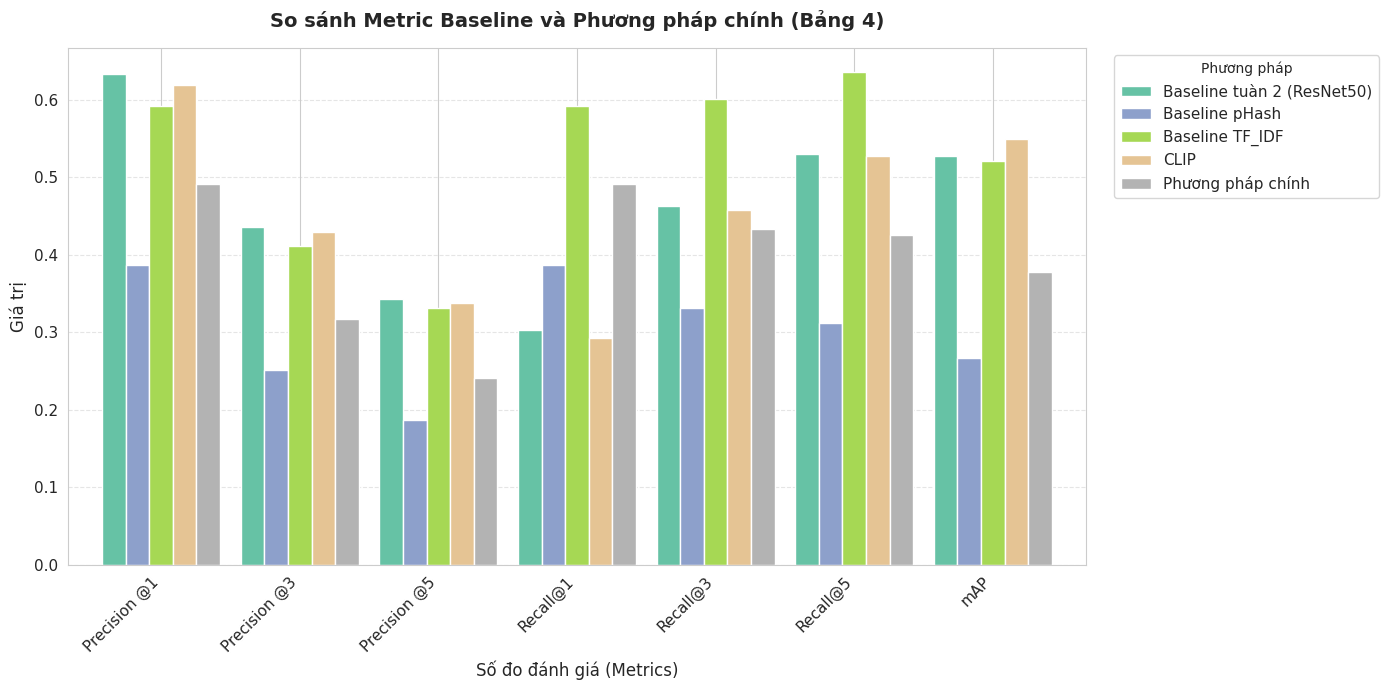

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Chuẩn bị dữ liệu được trích xuất từ hình ảnh
# Lưu ý: dữ liệu được tổng hợp từ cả hai phần trên và dưới của bảng.
data = {
    'Metric': [
        'Precision @1', 'Precision @3', 'Precision @5',
        'Recall@1', 'Recall@3', 'Recall@5', 'mAP'
    ],
    'Baseline tuàn 2 (ResNet50)': [
        0.6328, 0.4362, 0.3422, # Các số đo Precision
        0.3022, 0.4633, 0.5293, 0.5268  # Các số đo Recall & mAP
    ],
    'Baseline pHash': [
        0.3872, 0.2514, 0.1871, # Các số đo Precision
        0.3872, 0.3307, 0.3118, 0.2667  # Các số đo Recall & mAP
    ],
    'Baseline TF_IDF': [
        0.5922, 0.4108, 0.3313, # Các số đo Precision
        0.5922, 0.6001, 0.6349, 0.5204  # Các số đo Recall & mAP
    ],
    'CLIP': [  # Đây là cột CLIP mà bạn nhắc
        0.6186, 0.4286, 0.3373, # Các số đo Precision
        0.2927, 0.4575, 0.5266, 0.5492  # Các số đo Recall & mAP
    ],
    'Phương pháp chính': [
        0.4914, 0.3164, 0.2412, # Các số đo Precision
        0.4914, 0.4334, 0.4249, 0.3776  # Các số đo Recall & mAP
    ]
}

# 2. Chuyển đổi dữ liệu thành một pandas DataFrame
df = pd.DataFrame(data)
# Đặt cột 'Metric' làm chỉ mục (index) để dễ vẽ các số đo trên trục x
df.set_index('Metric', inplace=True)

# 3. Vẽ DataFrame dưới dạng biểu đồ cột
# Tôi đặt rotation=0 cho các nhãn trục x để dễ đọc hơn.
fig, ax = plt.subplots(figsize=(14, 7))
df.plot(kind='bar', ax=ax, rot=0, width=0.85, cmap='Set2')

# 4. Cấu hình chi tiết biểu đồ
plt.title('So sánh Metric Baseline và Phương pháp chính (Bảng 4)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Giá trị', fontsize=12)
plt.xlabel('Số đo đánh giá (Metrics)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11) # Xoay nhãn trục x và căn phải để tránh chồng chéo
plt.yticks(fontsize=11)
plt.legend(title='Phương pháp', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11) # Di chuyển chú thích ra ngoài sang bên phải
plt.grid(axis='y', linestyle='--', alpha=0.5) # Thêm đường lưới ngang để dễ so sánh

# Làm cho bố cục chặt chẽ hơn và hiển thị biểu đồ
plt.tight_layout()

# Tùy chọn: Lưu biểu đồ vào file kết quả theo đường dẫn mẫu của bạn
# results_dir = "/content/drive/MyDrive/DoAnPython/project/results"
# os.makedirs(results_dir, exist_ok=True)
# plt.savefig(os.path.join(results_dir, "bieu_do_metrics_so_sanh.png"), dpi=300)

# Hiển thị biểu đồ
plt.show()